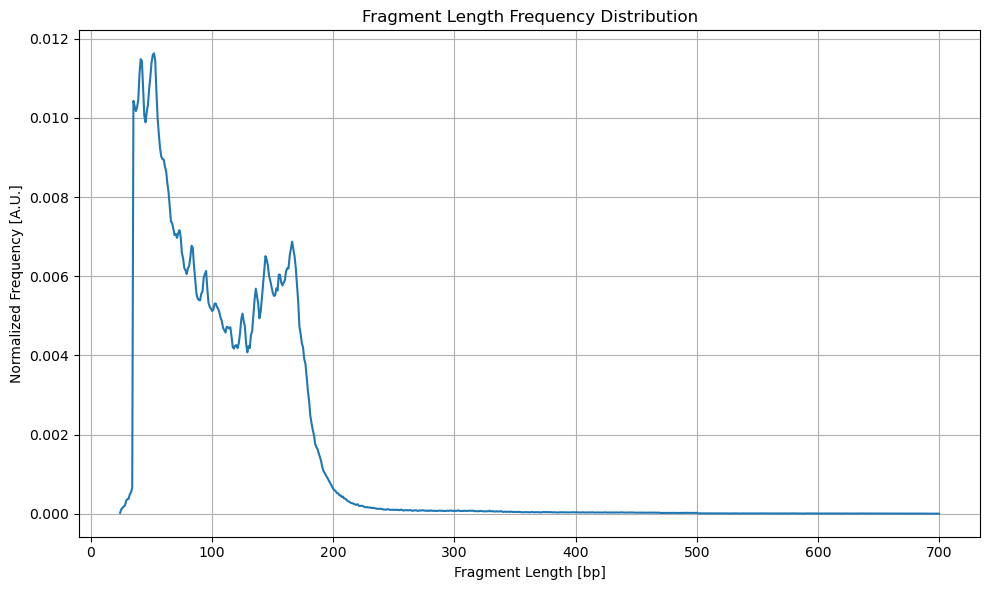

In [3]:
import gzip
from collections import Counter
import matplotlib.pyplot as plt

fragment_lengths = []

try:
    with gzip.open('query.bed.gz', 'rt', errors='ignore') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                try:
                    start = int(parts[1])
                    end = int(parts[2])
                    length = end - start
                    if length > 0:
                        fragment_lengths.append(length)
                except ValueError:
                    continue  # Skip lines with invalid number formatting
except EOFError:
    print("⚠ Warning: Reached unexpected end of file. The file may be corrupted.")

# Check if we got any valid fragments
if not fragment_lengths:
    print("❌ No valid fragment lengths found.")
else:
    # Count and normalize
    length_counts = Counter(fragment_lengths)
    total_fragments = sum(length_counts.values())
    normalized_freq = {length: count / total_fragments for length, count in length_counts.items()}

    # Sort for plotting
    sorted_lengths = sorted(normalized_freq.items())
    x_vals = [length for length, freq in sorted_lengths]
    y_vals = [freq for length, freq in sorted_lengths]

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, y_vals, linewidth=1.5)
    plt.xlabel("Fragment Length [bp]")
    plt.ylabel("Normalized Frequency [A.U.]")
    plt.title("Fragment Length Frequency Distribution")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

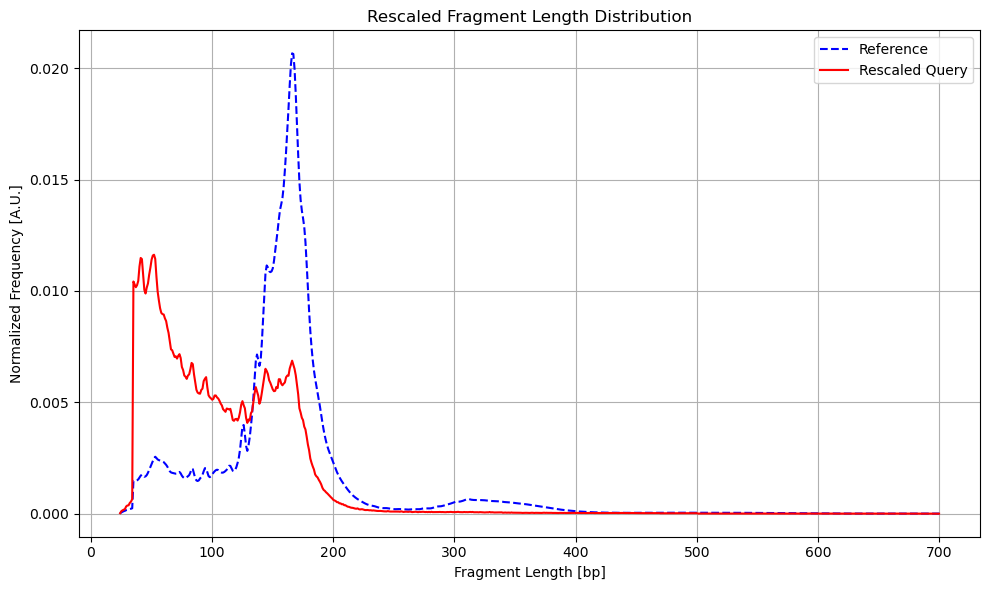

In [5]:
import gzip
import random
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

# Step 1: Load reference distribution from a file
ref_dist = {}
with open("reference.hist", "r") as file:
    for line in file:
        if line.strip():
            fragment_size, frequency = line.strip().split()
            ref_dist[int(fragment_size)] = float(frequency)

# Step 2: Read the gzipped query file and calculate fragment sizes
fragment_dict = defaultdict(list)  # Store fragments by size
with gzip.open("query.bed.gz", "rt") as file:
    for line in file:
        cols = line.strip().split()
        if len(cols) >= 3:
            try:
                start_pos = int(cols[1])
                end_pos = int(cols[2])
                frag_length = end_pos - start_pos
                if frag_length > 0:
                    fragment_dict[frag_length].append(line.strip())
            except ValueError:
                continue

# Step 3: Compute frequency of fragment lengths in the query
fragment_counts = {length: len(lines) for length, lines in fragment_dict.items()}
total_fragments = sum(fragment_counts.values())
query_frequencies = {length: count / total_fragments for length, count in fragment_counts.items()}

# Step 4: Rescale (subsample) the query data to match the reference distribution
scaling_factors = []
for frag_length in ref_dist:
    if frag_length in query_frequencies and query_frequencies[frag_length] > 0:
        scaling_factors.append(ref_dist[frag_length] / query_frequencies[frag_length])
scaling_factor = min(scaling_factors) if scaling_factors else 0

# Step 5: Perform subsampling of query data based on the scaling factor
adjusted_fragments = []
for frag_length in ref_dist:
    if frag_length in fragment_dict:
        target_count = int(ref_dist[frag_length] / scaling_factor * total_fragments)
        available_fragments = fragment_dict[frag_length]
        if target_count > len(available_fragments):
            sampled_fragments = available_fragments
        else:
            sampled_fragments = random.sample(available_fragments, target_count)
        adjusted_fragments.extend(sampled_fragments)

# Step 6: Compute and normalize the fragment lengths for the rescaled data
adjusted_lengths = [int(line.split()[2]) - int(line.split()[1]) for line in adjusted_fragments]
adjusted_count = Counter(adjusted_lengths)
total_adjusted = sum(adjusted_count.values())
normalized_adjusted = {length: count / total_adjusted for length, count in adjusted_count.items()}

# Step 7: Plot the reference and rescaled query distributions
plt.figure(figsize=(10, 6))

# Plot reference distribution
ref_lengths = sorted(ref_dist.keys())
ref_values = [ref_dist[length] for length in ref_lengths]
plt.plot(ref_lengths, ref_values, label="Reference", color='blue', linestyle='--')

# Plot rescaled query distribution
rescaled_lengths = sorted(normalized_adjusted.keys())
rescaled_values = [normalized_adjusted.get(length, 0) for length in rescaled_lengths]
plt.plot(rescaled_lengths, rescaled_values, label="Rescaled Query", color='red')

# Labels and title
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Rescaled Fragment Length Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

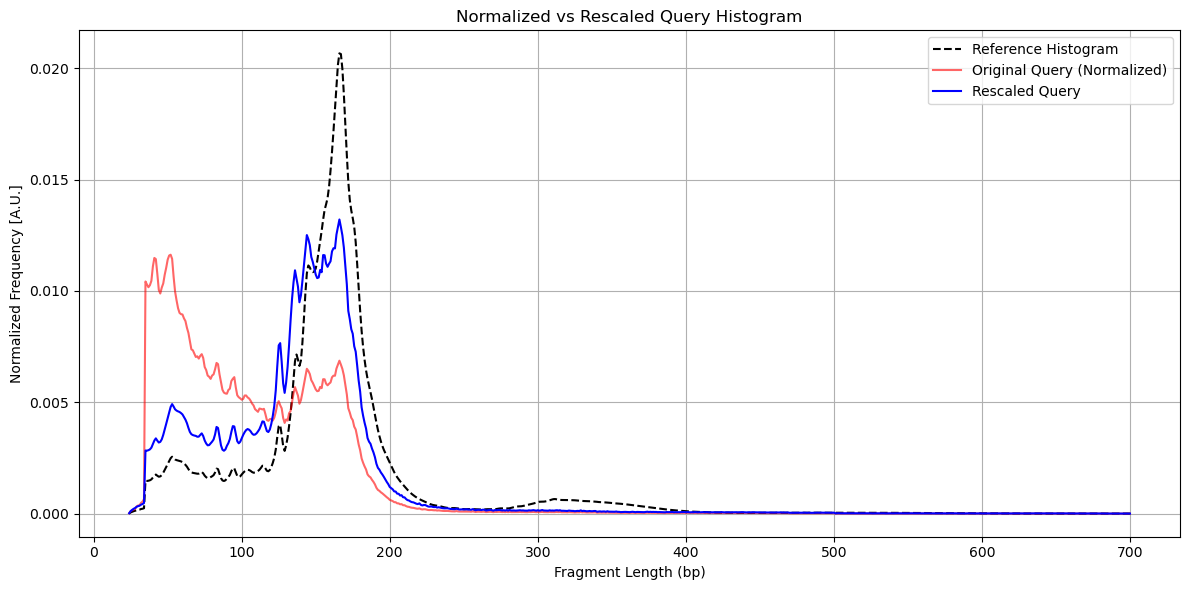

In [6]:
import matplotlib.pyplot as plt
from collections import Counter
import random

ref_counter = {}
with open("reference.hist") as f:
    for line in f:
        length, freq = line.strip().split()
        ref_counter[int(length)] = float(freq)

# -------------------------------
# Normalize original query histogram
total = len(fragment_lengths)
query_counter = Counter(fragment_lengths)
query_normalized = {k: v / total for k, v in query_counter.items()}

# -------------------------------
# Subsample query to match reference
rescaled_fragments = []
for length, ref_freq in ref_counter.items():
    desired_count = int(ref_freq * total)
    available = [l for l in fragment_lengths if l == length]
    if len(available) > desired_count:
        rescaled_fragments.extend(random.sample(available, desired_count))
    else:
        rescaled_fragments.extend(available)

# Normalize rescaled query
rescaled_counter = Counter(rescaled_fragments)
rescaled_total = sum(rescaled_counter.values())
rescaled_normalized = {k: v / rescaled_total for k, v in rescaled_counter.items()}

# -------------------------------
# Plot normalized and rescaled query histograms on same graph
all_lengths = sorted(set(query_normalized.keys()) | set(rescaled_normalized.keys()) | set(ref_counter.keys()))
query_y = [query_normalized.get(k, 0.0) for k in all_lengths]
rescaled_y = [rescaled_normalized.get(k, 0.0) for k in all_lengths]
ref_y = [ref_counter.get(k, 0.0) for k in all_lengths]

plt.figure(figsize=(12, 6))
plt.plot(all_lengths, ref_y, label="Reference Histogram", linestyle="--", color="black")
plt.plot(all_lengths, query_y, label="Original Query (Normalized)", alpha=0.6, color="red")
plt.plot(all_lengths, rescaled_y, label="Rescaled Query", color="blue")
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Normalized vs Rescaled Query Histogram")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
